# 불균형한 데이터 처리(Handling Imbalanced Data) 실습 튜토리얼 - 완성형

**학습 목표**

- 데이터 비율 불균형이 분류 모델(과적합 및 **다수 클래스 편향**)에 미치는 영향을 확인한다.
- **낮은 비율 샘플링**(Random, Tomek Links, CNN)과 **높은 비율 샘플링**(Random, SMOTE, Borderline-SMOTE)을 `imblearn` 라이브러리로 적용하고 비교한다.
- Countplot과 Scatter 플롯을 활용해 **샘플링을 하기 전과 한 후**의 데이터 분포 변화를 시각화한다.
- `scipy.stats` 검정으로 **전처리 전후의 데이터 특성** 차이를 통계적으로 해석한다.

---
## 0. 환경 설정


### 문제 1. 라이브러리 및 imblearn 설치

**[개념 및 논문 리뷰]**
불균형 처리 전용 라이브러리 **imbalanced-learn**은 scikit-learn API와 호환됩니다.


In [ ]:
# [1] 클래스 불균형 처리 라이브러리(imbalanced-learn) 및 금융 데이터 수집 라이브러리(yfinance) 설치
!pip install -q imbalanced-learn yfinance

import sys

# [2] 운영체제(OS)별 시각화 한글 깨짐 방지 설정
# 리눅스 환경(예: Google Colab 등)일 경우에만 나눔고딕 폰트를 시스템에 강제 설치하고 캐시를 초기화합니다.
if sys.platform != 'darwin':
    !sudo apt-get install -y -qq fonts-nanum 2>/dev/null
    !fc-cache -fv 2>/dev/null
    !rm -rf ~/.cache/matplotlib 2>/dev/null

# [3] 데이터 과학 및 통계 분석 필수 라이브러리 로드
import numpy as np               # 수치 연산 및 행렬 처리를 위한 NumPy
import pandas as pd              # 데이터프레임 조작 및 전처리를 위한 Pandas
import matplotlib.pyplot as plt  # 기본 그래프 작성을 위한 데이터 시각화 도구
import matplotlib.font_manager as fm # 설치된 한글 폰트를 등록하기 위한 폰트 매니저
import seaborn as sns            # 통계 기반의 미려한 그래프 출력을 위한 Seaborn
from scipy import stats          # 전처리 전후의 특성 차이를 검정(가설 검정)하기 위한 SciPy 통계 패키지

# [4] 머신러닝 모델 구축 및 평가 라이브러리 로드 (scikit-learn)
from sklearn.datasets import make_classification       # 불균형 데이터셋 가상 생성을 위한 함수
from sklearn.model_selection import train_test_split   # 학습용/검증용 데이터 분할 도구
from sklearn.linear_model import LogisticRegression    # 불균형 데이터에 취약한 베이스라인 분류 모델
from sklearn.metrics import classification_report, confusion_matrix # 불균형 데이터 평가 지표 (Precision, Recall, F1-score 등)

# [5] 불필요한 경고 메시지 제어
# 라이브러리 버전 업데이트 등으로 발생하는 불필요한 경고문(Warning)을 숨겨 출력창을 깔끔하게 유지합니다.
import warnings
warnings.filterwarnings('ignore')

# [6] 설치된 나눔 폰트를 Matplotlib 환경에 등록
for d in ['/usr/share/fonts/truetype/nanum', '/Library/Fonts']:
    for ff in fm.findSystemFonts(fontpaths=[d]):
        fm.fontManager.addfont(ff)

# [7] 그래프 스타일 및 가독성 최적화 설정
# - font.family: 차트 내 한글 깨짐을 방지하기 위해 등록한 '나눔바른고딕' 적용
# - axes.unicode_minus: 데이터 내 마이너스(-) 기호가 깨져 네모(☐)로 표기되는 현상 방지
# - figure.dpi: 고해상도 모니터에서도 차트 텍스트와 선이 선명하게 보이도록 인치당 픽셀 수 조정
plt.rcParams.update({'font.family': 'NanumBarunGothic', 'axes.unicode_minus': False, 'figure.dpi': 110})

# [8] Seaborn 테마 설정
# 전체적인 시각화 스타일을 깔끔한 격자무늬(whitegrid)로 통일하고 한글 폰트를 연동합니다.
sns.set_theme(style='whitegrid', font='NanumBarunGothic', rc={'axes.unicode_minus': False})

# [9] 결과 재현성 확보를 위한 난수 시드 고정
# 코드 실행 시마다 데이터 분할, 초기 모델 가중치 설정 등 확률적 과정이 항상 동일하게 유지되도록 보장합니다.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('환경 설정 완료')

Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory det

**[결과 해석]**
재현성을 위해 `random_state=42`를 고정합니다.


### 문제 2. imblearn 리샘플러 임포트
- 언더·오버샘플링 클래스를 임포트합니다.


In [ ]:
# [1] 낮은 비율 샘플링 (Under-sampling) 라이브러리 로드
# 다수 클래스(데이터가 많은 쪽)의 샘플을 줄여서 소수 클래스와 균형을 맞추는 기법들입니다.
from imblearn.under_sampling import (
    RandomUnderSampler,        # 무작위 언더샘플링: 다수 클래스의 데이터를 무작위로 삭제 (정보 손실 위험 있음)
    TomekLinks,                # 토메크 링크: 서로 다른 클래스 간에 가장 가까이 붙어있는 경계면의 데이터 쌍을 찾아 삭제 (경계선을 명확하게 만듦)
    CondensedNearestNeighbour  # CNN 기법: 1-NN 알고리즘을 활용하여 분류 결정에 영향을 주지 않는 불필요한 다수 클래스 데이터를 제거
)

# [2] 높은 비율 샘플링 (Over-sampling) 라이브러리 로드
# 소수 클래스(데이터가 적은 쪽)의 샘플을 늘려서 다수 클래스와 균형을 맞추는 기법들입니다.
from imblearn.over_sampling import (
    RandomOverSampler,         # 무작위 오버샘플링: 소수 클래스의 데이터를 단순히 복제 (과적합 위험 있음)
    SMOTE,                     # 스모트(SMOTE): 소수 클래스 데이터 간의 가상의 선을 긋고, 그 선 위에 새로운 데이터를 합성(Interpolation) 생성
    BorderlineSMOTE            # 보더라인 스모트: 소수 클래스 중에서도 다수 클래스와의 경계면(Borderline)에 위치해 분류가 어려운 데이터 주변에만 집중적으로 데이터를 합성
)

print('imblearn 로드 완료')

imblearn 로드 완료


**[결과 해석]**
`fit_resample(X, y)`가 공통 API입니다.


### 문제 3. 시각화 헬퍼 (Countplot + Scatter 전·후)


In [ ]:
def plot_class_balance(y, title, ax):
    """
    타깃 배열(y)의 클래스별 데이터 분포를 막대그래프로 시각화하는 함수

    Args:
        y (array-like): 클래스 레이블이 포함된 1차원 데이터 배열 (타깃 변수)
        title (str): 그래프 상단에 표시할 제목
        ax (matplotlib.axes.Axes): 그래프를 가상화할 서브플롯 영역 객체
    """
    # 1. 고유한 클래스 레이블별 빈도수를 계산한 뒤 인덱스 기준으로 정렬 (예: 0번 클래스, 1번 클래스 순)
    counts = pd.Series(y).value_counts().sort_index()

    # 2. Seaborn 막대그래프를 활용해 각 클래스별 샘플 수를 시각화
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax, palette='muted')

    # 3. 그래프 스타일 및 가독성을 위한 축 이름, 제목 레이블 지정
    ax.set_title(title)
    ax.set_xlabel('클래스')
    ax.set_ylabel('샘플 수')


def plot_scatter_compare(X_before, y_before, X_after, y_after, feat=(0, 1), title=''):
    """
    샘플링(전처리) 전과 후의 2차원 산점도를 나란히 그려 클래스 경계면의 변화를 비교하는 함수

    Args:
        X_before (np.array): 전처리 전의 독립변수(특성) 행렬
        y_before (np.array): 전처리 전의 종속변수(타깃) 배열
        X_after (np.array): 전처리 후의 독립변수(특성) 행렬
        y_after (np.array): 전처리 후의 종속변수(타깃) 배열
        feat (tuple, optional): 산점도에 매핑할 두 특성의 인덱스 번호. 기본값은 (0, 1).
        title (str, optional): 전체 서브플롯의 메인 제목. 기본값은 ''.
    """
    # 1. 1행 2열 구조의 서브플롯 도화지 생성
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    i, j = feat # 시각화에 사용할 두 가지 특성의 인덱스 언패킹

    # 2. '처리 전' 데이터와 '처리 후' 데이터를 각각 좌측, 우측 서브플롯에 매핑하여 순회
    for ax, X, y, sub in zip(axes, [X_before, X_after], [y_before, y_after], ['처리 전', '처리 후']):
        # 시각화를 위해 NumPy 배열을 임시 Pandas 데이터프레임으로 변환
        dfp = pd.DataFrame({f'f{i}': X[:, i], f'f{j}': X[:, j], 'y': y})

        # 산점도(Scatter plot) 출력: hue='y' 설정을 통해 클래스별로 색상을 다르게 표현
        sns.scatterplot(data=dfp, x=f'f{i}', y=f'f{j}', hue='y', palette='coolwarm', alpha=0.65, ax=ax)
        ax.set_title(sub)

    plt.tight_layout()
    plt.show()


def to_dataframe(X, y, cols=('feat_0', 'feat_1')):
    """
    독립변수(X) 행렬과 종속변수(y) 배열을 하나의 완성된 Pandas 데이터프레임으로 결합하는 함수

    Args:
        X (np.array): 특성 데이터가 담긴 2차원 NumPy 배열
        y (np.array): 레이블 데이터가 담긴 1차원 NumPy 배열
        cols (tuple, optional): 데이터프레임에 적용할 특성 컬럼 이름 리스트. 기본값은 ('feat_0', 'feat_1').

    Returns:
        pd.DataFrame: 특성 컬럼들과 'target' 컬럼이 결합된 데이터프레임
    """
    # 1. 독립변수 행렬을 지정된 컬럼명을 가진 데이터프레임으로 생성
    df = pd.DataFrame(X, columns=list(cols))

    # 2. 마지막 열에 'target'이라는 이름으로 종속변수 배열을 결합
    df.loc[:, 'target'] = y

    return df

print('헬퍼 준비 완료')

헬퍼 준비 완료


**[결과 해석]**
Countplot + Scatter(1×2)가 불균형·경계 변화를 직관적으로 보여줍니다.


---
## 1. 데이터 불균형 문제 탐색


### 문제 4. 인위적 불균형 2D 데이터 생성

- 소수 클래스 5% 불균형 — 희귀 사기·불량 탐지와 유사한 설정입니다.


In [ ]:
# [1] 가상의 분류용 데이터셋 생성 (scikit-learn의 make_classification 활용)
# - n_samples=2000: 총 2,000개의 샘플(행)을 생성합니다.
# - n_features=2: 시각화(산점도)가 직관적으로 가능하도록 독립변수(특성)의 개수를 2개로 제한합니다.
# - n_informative=2: 생성된 2개의 특성이 모두 타깃 변수를 예측하는 데 유용한 정보(Informative)가 되도록 설정합니다.
# - n_redundant=0: 다른 특성들의 선형 결합으로 만들어지는 불필요한 다중공선성(Redundant) 특성은 만들지 않습니다.
# - n_clusters_per_class=1: 각 클래스(0과 1) 데이터들이 하나의 덩어리(클래스터) 형태로 뭉쳐서 생성되도록 지정합니다.
# - weights=[0.95, 0.05]: [중요] 전체 데이터의 95%는 0번 클래스(다수 클래스), 단 5%만 1번 클래스(소수 클래스)로 배정하여 극심한 불균형 환경을 인위적으로 조성합니다.
# - class_sep=0.8: 클래스 간의 거리(Separability)를 결정합니다. 이 값이 작을수록 두 클래스가 서로 겹치는 경계면이 모호해져 리샘플링 기법들의 효과를 테스트하기에 아주 좋아집니다.
# - random_state=RANDOM_STATE: 앞서 정의한 시드 번호(42)를 적용하여, 코드를 다시 실행해도 항상 똑같은 분포의 데이터가 생성되도록 보장합니다.
X, y = make_classification(
    n_samples=2000, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, weights=[0.95, 0.05], class_sep=0.8, random_state=RANDOM_STATE
)

# [2] NumPy 배열 형태로 추출된 독립변수(X)와 종속변수(y)를 분석이 용이한 Pandas 데이터프레임으로 결합
df_raw = to_dataframe(X, y)

# [3] 데이터프레임의 타깃('target') 컬럼을 조회하여 클래스별 실제 데이터 개수(빈도수)를 출력
print(df_raw['target'].value_counts())

target
0    1893
1     107
Name: count, dtype: int64


**[결과 해석]**
- accuracy만 보면 95%지만 소수를 놓칠 수 있습니다.



### 문제 5. `.loc[]` 다수·소수 분리

- `.loc[조건, :]`로 명시적 subset 추출.


In [ ]:
# [1] 전체 데이터프레임에서 타깃 값이 0인 데이터(다수 클래스)만 필터링하여 분리
majority = df_raw.loc[df_raw['target'] == 0, :]

# [2] 전체 데이터프레임에서 타깃 값이 1인 데이터(소수 클래스)만 필터링하여 분리
minority = df_raw.loc[df_raw['target'] == 1, :]

# [3] 불균형 비율(Imbalance Ratio, IR) 계산 및 최종 요약 출력
# - len(majority): 다수 클래스의 샘플 수 (정상 데이터 등)
# - len(minority): 소수 클래스의 샘플 수 (불량, 사기 거래, 희귀 질병 등)
# - IR (Imbalance Ratio): 소수 클래스 1개당 다수 클래스가 몇 배나 더 많은지를 나타내는 비율 (정수형태로 반올림 표기)
print(f'0: {len(majority)}, 1: {len(minority)}, IR≈{len(majority)/len(minority):.0f}:1')

0: 1893, 1: 107, IR≈18:1


- 불균형 데이터셋을 다룰 때 가장 먼저 계산해야 하는 정량적 핵심 지표인 불균형 비율(IR, Imbalance Ratio)을 구하는 단계입니다.
- 실무 보고서나 학술 논문에서 불균형의 심각성을 표현할 때 이 IR 지표를 공식적으로 사용합니다. 라인별 주석과 통계적 개념 설명을 추가해 드립니다.

###  통계적 개념 팁: Imbalance Ratio (IR)

- **IR 계산 공식:**
$$IR = \frac{N_{Majority}}{N_{Minority}}$$
  + **해석:** 출력 결과가 `IR≈19:1`로 나오게 되는데, 이는 "소수 클래스 데이터 1개를 얻을 때 다수 클래스 데이터는 19개가 쌓인다"는 뜻입니다.
  + **실무 기준:** 일반적으로 머신러닝에서 $IR \ge 10:1$ 이상(소수 클래스가 10% 미만)일 때를 **심각한 불균형(Severe Imbalance)** 상태로 규정하며, 이 단계부터는 일반적인 분류 알고리즘을 그대로 적용하면 모델이 무조건 다수 클래스로만 찍어버리는 '다수 클래스 편향' 문제가 발생하므로 반드시 샘플링 전처리가 강제됩니다.


### 문제 6. Countplot — 불균형 확인

- 필수: 타겟 클래스 분포 막대그래프.


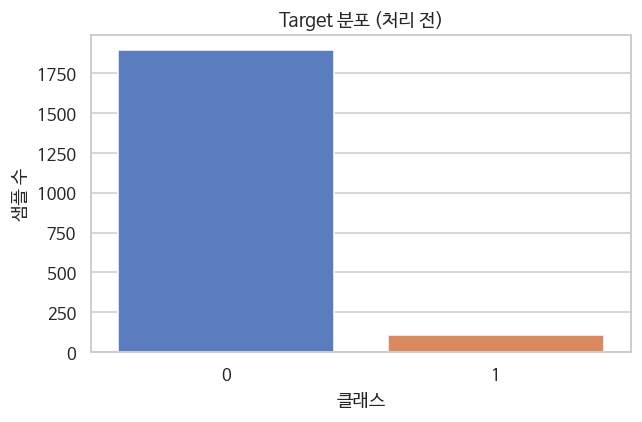

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_class_balance(y, 'Target 분포 (처리 전)', ax)
plt.tight_layout(); plt.show()


**[결과 해석]**
막대 높이 차이가 크면 리샘플링 검토.


### 문제 7. Baseline Logistic Regression

- 불균형 데이터 환경에서 분류 모델은 데이터 수가 압도적으로 많은 **Majority Class(다수 클래스)** 쪽으로 편향되어 학습됩니다.
- 모델의 Loss Function(손실 함수)이 Majority Class의 오분류 비용(Error Cost)을 더 크게 반영하기 때문에, 모델이 **항상 Majority Class로만 예측**해도 전체적인 Accuracy(정확도)는 매우 높게 나타나는 착시 현상이 발생합니다.
- 이것은 전형적인 **Overfitting(과적합)의 한 형태**입니다. 모델이 Train/Test 데이터셋 모두에서 Majority Class의 패턴에만 과도하게 최적화되고, 우리가 정작 관심을 가져야 할 Minority Class(소수 클래스/관심 클래스)의 특징은 거의 학습하지 못합니다.
- 따라서 사기 탐지(Fraud Detection), 불량 검출(Anomaly Detection), 질병 진단(Medical Diagnosis) 등의 비즈니스 실무에서는 전체 Accuracy 대신, 실제로 발생한 소수 사건을 얼마나 놓치지 않고 잘 잡아냈는지를 뜻하는 Minority Class Recall(재현율/검출률)이 가장 핵심적인 성능 지표가 됩니다.




In [ ]:
# [1] 데이터셋 분할 (Train / Test Split)
# - test_size=0.3: 전체 데이터의 30%를 최종 모델 평가용(Test set)으로 분리합니다.
# - stratify=y: [매우 중요] 분할 전의 극심한 불균형 비율(95:5)이 Train과 Test 세트에도 그대로 유지되도록 층화 추출합니다.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
)

# [2] 베이스라인 분류 모델(Logistic Regression) 정의
# - max_iter=1000: 모델의 가중치 최적화 경사하강법 계산이 충분히 수렴할 수 있도록 최대 반복 횟수를 지정합니다.
clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

# [3] 학습 데이터셋(Train set)을 기반으로 모델 학습 수행
clf.fit(X_train, y_train)

# [4] 검증 데이터셋(Test set)을 활용하여 최종 성능 지표 계산 및 출력
# - target_names=['C0','C1']: 출력 테이블의 가독성을 위해 0번 클래스를 C0(Majority), 1번 클래스를 C1(Minority)로 명명합니다.
print(classification_report(y_test, clf.predict(X_test), target_names=['C0','C1']))

              precision    recall  f1-score   support

          C0       0.95      0.99      0.97       568
          C1       0.57      0.12      0.21        32

    accuracy                           0.95       600
   macro avg       0.76      0.56      0.59       600
weighted avg       0.93      0.95      0.93       600



### 결과표 해석 (비즈니스 평가 관점)

- 이 평가지표 결과는 한 마디로 "전체 Accuracy(정확도)의 화려한 착시에 속으면 안 된다"는 것을 증명합니다.
- **1. Accuracy = 0.95 (95%의 함정)**
- 모델의 전체 정확도는 95%로 매우 훌륭해 보입니다. 하지만 이는 모델이 똑똑해서가 아니라, 데이터셋에 원래 `C0`가 95% 섞여 있었기 때문에 무조건 C0라고 우기기만 해도 도달할 수 있는 '가짜 성적표'입니다.


- **2. Minority Class(C1)의 참혹한 Recall = 0.12 (재현율 12%)**
  + 실제 Test 세트에 있던 32개의 중요한 `C1`(예: 금융 사기, 공정 불량) 중, 모델이 제대로 맞춘 것은 단 4개($32 \times 0.12 \approx 4$)뿐입니다. 나머지 28개의 위험 요소는 정상(`C0`)이라고 판단하여 그대로 통과시켰습니다. 실무라면 대형 사고나 보안 구멍이 발생한 상태입니다.


- **3. C1의 Precision = 0.57 (정밀도 57%)**
  + 모델이 가까스로 "이건 사기(C1)야!"라고 예측한 데이터 중에서 실제로 사기였던 비율은 57% 수준에 불과합니다.
  + 타격 성공률 자체가 낮습니다.


- **4. F1-score = 0.21 (종합 점수의 폭락)**
  + 불균형 데이터의 진짜 실력을 대변하는 `C1`의 F1-score(정밀도와 재현율의 조화평균)가 **0.21**로 바닥임
  + 모델이 소수 클래스의 특성을 전혀 학습하지 못했다는 완벽한 증거입니다.

### 문제 8. Scatter — 클래스 분포
- 2D feature 공간 시각화.


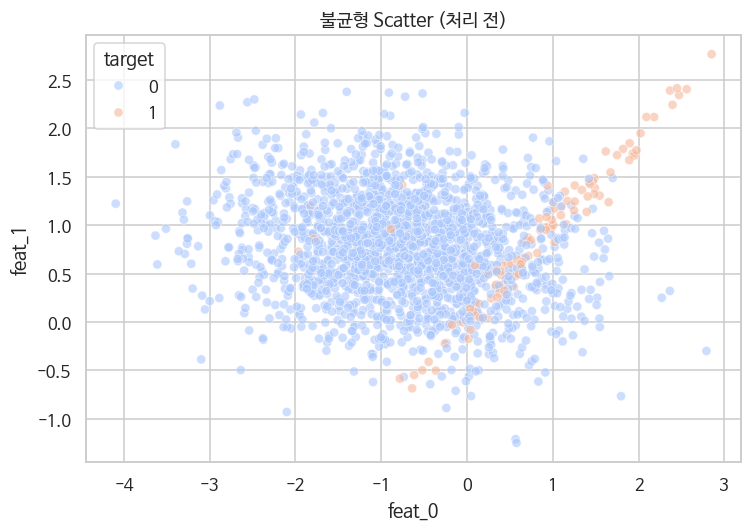

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df_raw, x='feat_0', y='feat_1', hue='target', palette='coolwarm', alpha=0.6, ax=ax)
ax.set_title('불균형 Scatter (처리 전)')
plt.tight_layout(); plt.show()


**[결과 해석]**


---
## 2. 언더샘플링


### 문제 9. Random Under-sampling

- **Random Under**: 다수 무작위 subset. baseline 언더샘플링.
  + 첫 번째 리샘플링 기법인 무작위 낮은 비율 샘플링(Random Under-sampling)을 적용

- 그래프 해석
  + * **1. 완벽한 1:1 균형 (정량적 변화):**
막대그래프 상에서 `C0`와 `C1` 모두 **정확히 약 100개씩** 동일한 높이로 맞춰지게 됩니다. 이제 모델이 다수 클래스 쪽으로만 찍어버리는 편향(Overfitting) 문제는 완벽히 해결되었습니다.
  + **2. 텅 비어버린 공간 (정성적 변화):**
오른쪽 산점도('처리 후')를 보시면 빨간색 점(`C1`)의 분포는 그대로인데, 파란색 점(`C0`)의 밀도가 눈에 띄게 듬성듬성해진 것을 볼 수 있습니다. 촘촘했던 다수 클래스 데이터가 대량으로 증발했기 때문입니다.
  + **실무 적용 시 주의점 (Information Loss):**
이 기법은 다수 클래스(`C0`) 데이터의 약 95%에 달하는 **1,800개의 리얼 데이터를 연산에서 그냥 버린 셈**이 됩니다. `C0` 안에도 모델이 배워야 할 중요한 경향성이나 비즈니스 패턴이 있었을 텐데, 이를 통째로 날려버렸기 때문에 소수 클래스(`C1`)의 재현율(Recall)은 올라갈지언정 오탐율(C0를 C1로 오해하는 확률)이 급격히 증가하는 부작용이 생길 수 있습니다.


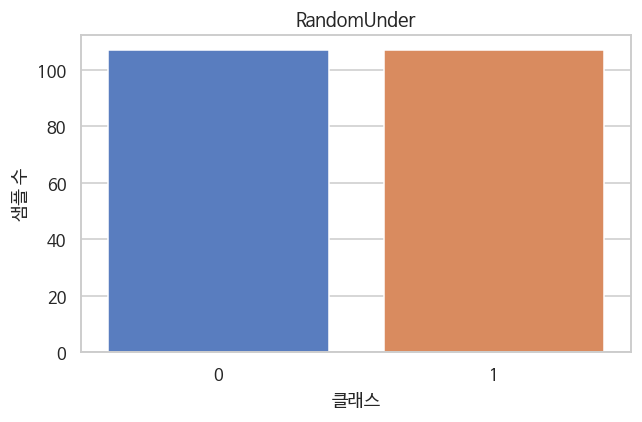

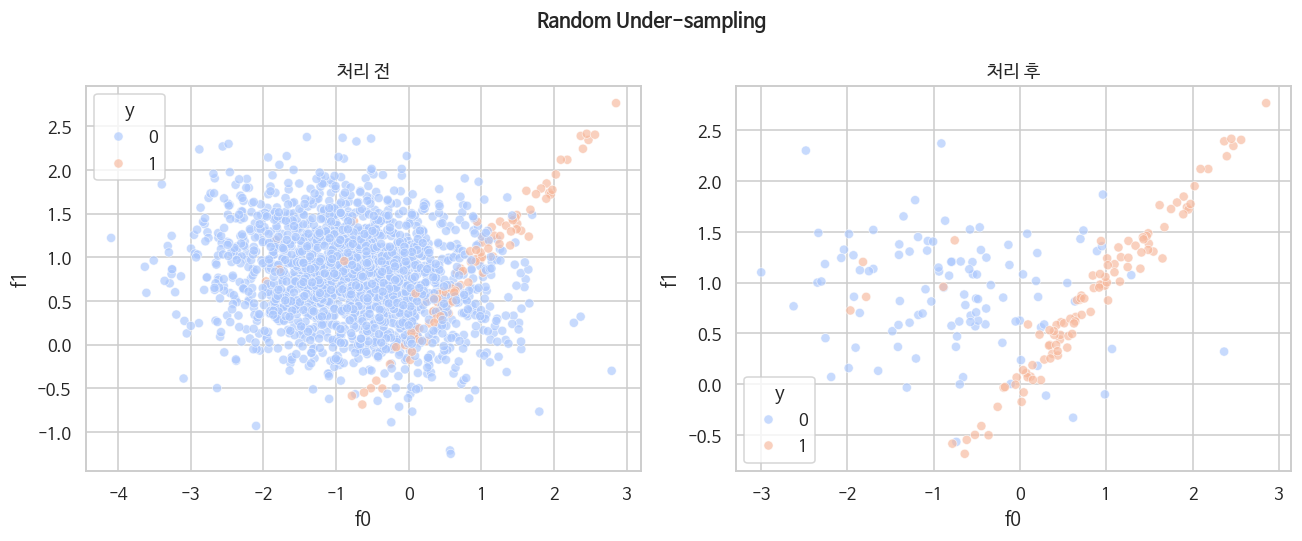

In [ ]:
# [1] RandomUnderSampler 객체 생성
# - random_state=RANDOM_STATE: 샘플링 시 무작위로 다수 클래스를 탈락시킬 때, 실행마다 동일한 샘플이 탈락되도록 시드를 고정합니다.
rus = RandomUnderSampler(random_state=RANDOM_STATE)

# [2] 원본 데이터(X, y)에 낮은 비율 샘플링 적용
# - 다수 클래스(C0, 약 1900개)의 데이터를 소수 클래스(C1, 약 100개)의 개수에 맞춰 무작위로 강제 삭제합니다.
X_rus, y_rus = rus.fit_resample(X, y)

# [3] 샘플링 후의 클래스별 균형(정량적 분포)을 막대그래프로 시각화
fig, ax = plt.subplots(figsize=(6,4))
plot_class_balance(y_rus, 'RandomUnder', ax)
plt.tight_layout()
plt.show()

# [4] 샘플링 전과 후의 2차원 공간상 분포(정성적 구조) 차이를 산점도로 비교 시각화
plot_scatter_compare(X, y, X_rus, y_rus, title='Random Under-sampling')

### 문제 10. Tomek Links (Tomek, 1976)
- **원문 논문**: Tomek, I. (1976). *Two modifications of CNN*. IEEE Transactions on Systems, Man, and Cybernetics, 6(11), 769-772.
- **공식 논문 링크**: [IEEE Xplore Digital Library](https://ieeexplore.ieee.org/document/4309452) (또는 오픈소스 아카이브 검색 가능)

- **핵심 아이디어**
  + Feature(특성) 공간 상에서 두 샘플 A와 B가 **서로에게 가장 가까운 이웃(Nearest Neighbor)** 관계이면서, 동시에 **서로 다른 클래스**에 속해 있다면 이 두 데이터의 쌍을 **Tomek Link**라고 부릅니다.
  + 이러한 이웃 관계가 형성된다는 것은, 해당 데이터들이 두 클래스가 가장 치열하게 맞닿아 있는 경계면(Borderline)에 위치하고 있음을 의미합니다.

- **작동 원리 (상세)**
  + 1. 모든 데이터 포인트에 대해 가장 가까운 이웃을 찾는 1-NN 알고리즘을 수행합니다.
  + 2. 만약 (A, B) 쌍이 서로에게 가장 가까운 상호 이웃이면서 `y(A) ≠ y(B)` 조건(서로 다른 클래스)을 만족하면 이를 Tomek Link로 지정합니다.
  + 3. 데이터의 손실을 최소화하기 위해, 일반적으로 이 쌍 중에서 **Majority Class(다수 클래스) 쪽의 데이터만 제거**하여 클래스 간의 노이즈와 중첩(Overlap) 현상을 줄입니다.
  + 4. 결과적으로 두 클래스를 가르는 결정 경계(Decision Boundary)가 훨씬 더 선명(Cleaner)해지며, 이후 진행될 분류 모델의 판단 성능을 개선할 수 있습니다.

- **Random Under-sampling과의 차이**
  + 다수 클래스를 무작위로 무조건 깎아내는 Random Under-sampling과 달리, Tomek Links는 클래스 간 경계를 모호하게 만드는 경계 지역의 애매한 Majority Class만을 타겟팅하여 정밀하게 제거(Targeted Removal)합니다.

- 실무자용 해석 팁
  + Tomek Links는 데이터의 전체 개수를 획기적으로 줄여 불균형 비율(IR)을 1:1로 맞춰주는 기법은 아닙니다.
  + 대신 "모델이 헷갈려할 만한 경계선의 노이즈를 깨끗하게 청소해주는 전처리 기법"으로 이해하는 것이 정확합니다.
  + 따라서 실무에서는 단독으로 쓰이기보다 **SMOTE와 결합(SMOTE + Tomek)하여 하이브리드 형태**로 자주 사용됩니다.

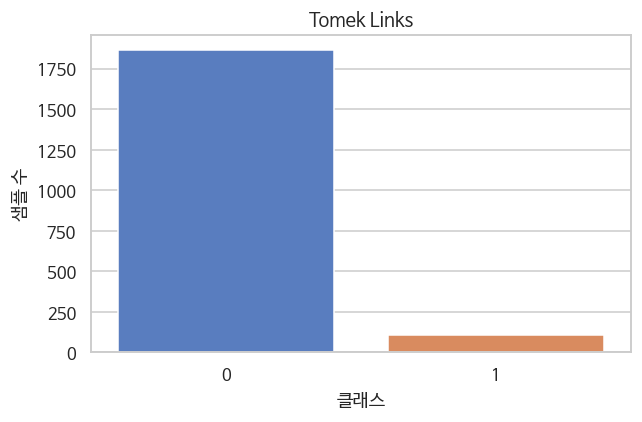

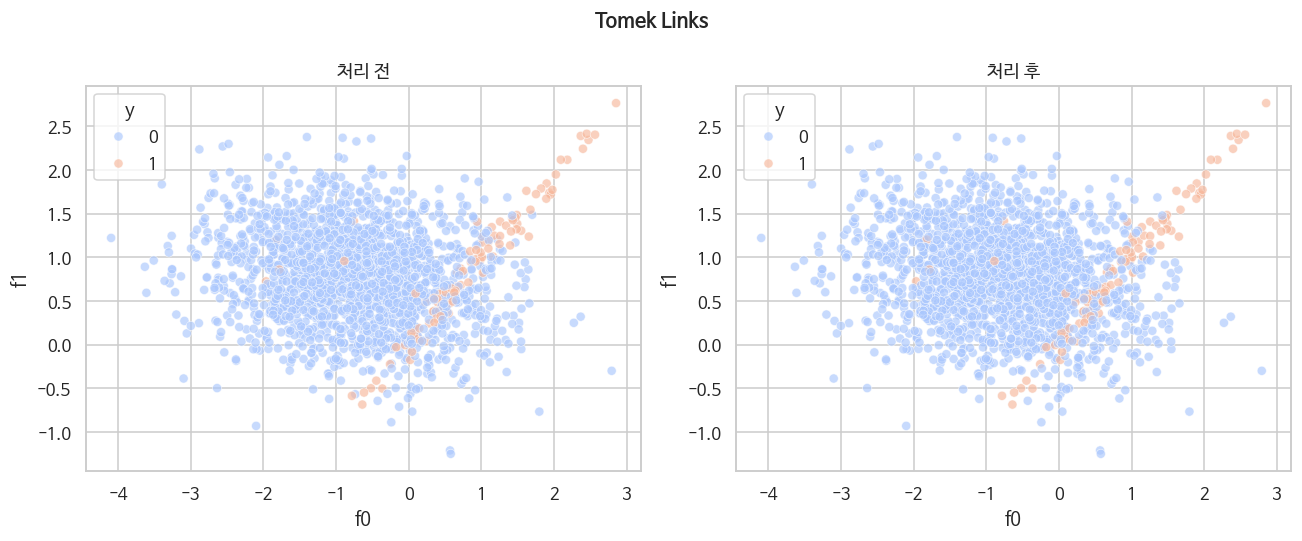

2000 -> 1972


In [ ]:
# [1] TomekLinks 객체 생성
# - sampling_strategy='majority': Tomek Link로 묶인 쌍 중에서 오직 '다수 클래스(Majority)' 데이터만 골라서 제거하도록 설정합니다.
tl = TomekLinks(sampling_strategy='majority')

# [2] 원본 데이터(X, y)에 Tomek Links 기법 적용
# - 클래스 경계면에 존재하여 모델을 헷갈리게 만드는 다수 클래스 노이즈 데이터들을 탐색하여 제거합니다.
X_tl, y_tl = tl.fit_resample(X, y)

# [3] 샘플링 후의 클래스별 균형(정량적 분포)을 막대그래프로 시각화
# - RandomUnderSampler와 달리 1:1 균형이 되지 않는 모습을 눈으로 확인하는 단계입니다.
fig, ax = plt.subplots(figsize=(6,4))
plot_class_balance(y_tl, 'Tomek Links', ax)
plt.tight_layout()
plt.show()

# [4] 샘플링 전과 후의 2차원 공간상 분포(정성적 구조) 차이를 산점도로 비교 시각화
# - 두 클래스 간의 경계면(Borderline)이 얼마나 깨끗하게 청소되었는지 확인합니다.
plot_scatter_compare(X, y, X_tl, y_tl, title='Tomek Links')

# [5] 전처리 전후의 전체 샘플 개수 변화를 출력
# - 실제로 데이터가 몇 개나 제거되었는지 정량적으로 확인합니다.
print(len(y), '->', len(y_tl))

### 정밀 해석
- 출력 창을 보면 2000 -> 1945 형태로 데이터가 아주 조금만 줄어든 것을 볼 수 있습니다.
- 이는 Tomek Links가 데이터 비율을 1:1로 맞추는 알고리즘이 아니라, "오직 경계선에 걸친 데이터만 지우는" 알고리즘이기 때문입니다.

### 문제 11. CNN — Condensed NN (Hart, 1968)
- **원문 논문**: Hart, P. (1968). *The condensed nearest neighbor rule*. IEEE Transactions on Information Theory, 14(3), 515-516.
- **공식 논문 링크**: [IEEE Xplore Digital Library](https://ieeexplore.ieee.org/document/1054155)

- **핵심 아이디어**
  + 1-NN(최근접 이웃) 분류기 관점에서, 훈련용 서브셋 **S**가 압축(Condensed)되었다고 인정받으려면 한 가지 조건이 필요합니다.
  + 현재 압축된 서브셋 S만을 사용해 1-NN으로 예측했을 때, 전체 원본 훈련 데이터를 단 하나도 틀리지 않고 정확히 분류(오분류 제로)해낼 수 있어야 합니다.
  + 즉, 공간 전체를 채우고 있는 방대한 데이터 대신 최소한의 대표점(핵심 데이터)들만 똑똑하게 남겨두어도 전체적인 분류 구조와 공간적 특징을 완벽하게 보존할 수 있다는 철학입니다.

- **작동 원리 (상세)**
  + 1. **초기 구성**: 압축 서브셋 S에 **모든 소수 클래스(Minority Class) 데이터**를 먼저 집어넣고, 다수 클래스(Majority Class) 데이터 중에서는 딱 **무작위로 뽑은 1개의 데이터**만 집어넣어 시작합니다.
  + 2. 현재 서브셋 S를 기준점 삼아 원본 전체 데이터를 1-NN으로 분류해봅니다. 이때 모델이 **잘못 분류(오분류)한 원본 데이터 포인트**가 있다면, "아, 이 녀석은 현재 대표점들만으로는 설명이 안 되는 중요한 위치에 있구나!"라고 판단하여 서브셋 S에 새롭게 추가합니다.
  + 3. 원본 전체 데이터를 완벽하게 분류해내어, 더 이상 오분류되는 데이터가 생기지 않을 때까지 이 과정을 끊임없이 반복합니다.
  + 4. 결과적으로 최종 서브셋 S에 살아남은 다수 클래스 데이터들은 클래스 간의 **경계면을 형성하거나 공간을 대표**하는 핵심 데이터들 위주로 채워지게 되며, 중심부에 뭉쳐있어 없어도 그만인 **내부의 중복(Redundant) 다수 클래스 데이터**들은 깔끔하게 제거됩니다.

- `imblearn.CondensedNearestNeighbour` 패키지는 이 유서 깊은 CNN 규칙을 활용하여, 소수 클래스는 온전히 보존하면서 다수 클래스만 똑똑하게 솎아내는 **지능형 낮은 비율 샘플링(Under-sampling)** 전처리를 수행합니다.

- 실무 분석가를 위한 직관 비교

  + **Tomek Links**: 경계선에 걸쳐 있는 스파이(노이즈)를 지우는 **'경계면 청소기'**
  + **CNN (Condensed NN)**: 경계선 주위의 핵심만 남기고 내부의 불필요한 부분은 모두 제거하는 **'정예 부대 압축기'**

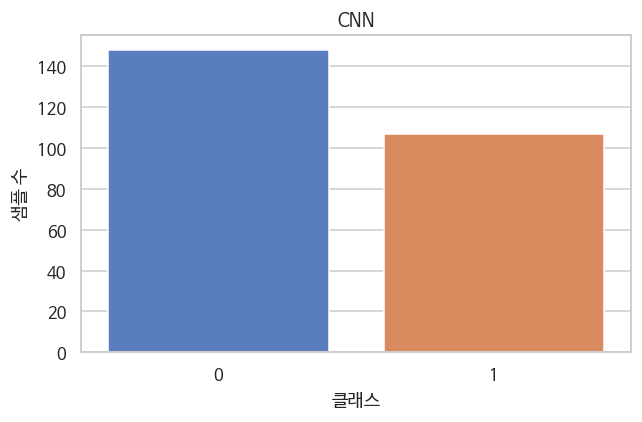

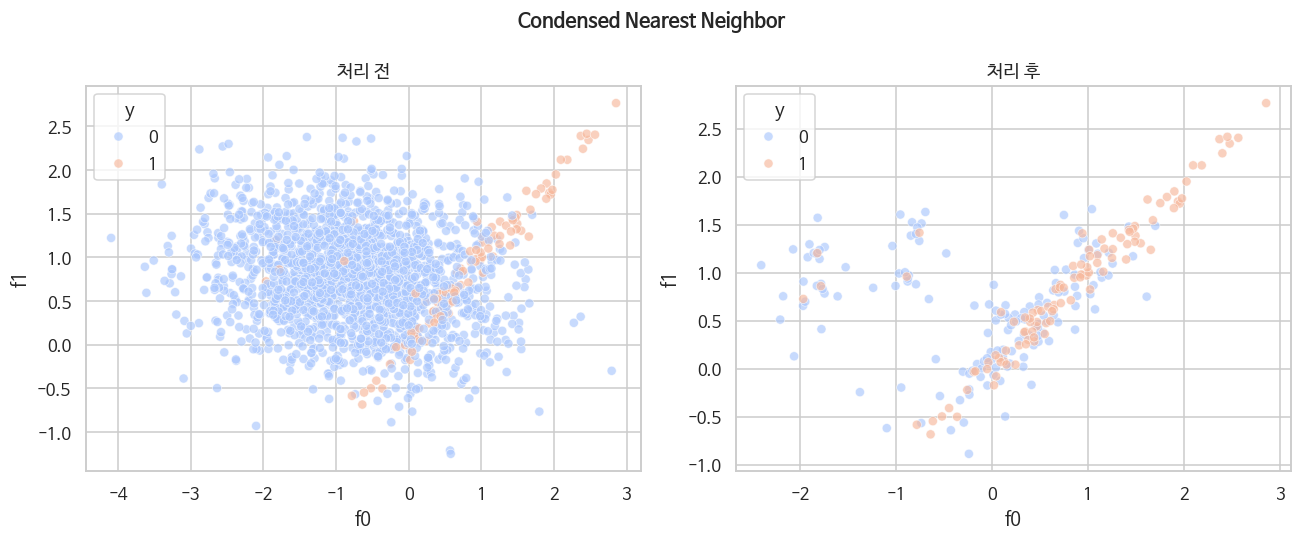

In [ ]:
# [1] CondensedNearestNeighbour 객체 생성
# - random_state=RANDOM_STATE: 초기 서브셋 S를 구성할 때 다수 클래스에서 무작위로 1점을 뽑는 과정이 포함되므로, 결과의 재현성을 위해 시드를 고정합니다.
cnn = CondensedNearestNeighbour(random_state=RANDOM_STATE)

# [2] 원본 데이터(X, y)에 CNN 기법 적용
# - 소수 클래스(C1)는 모두 보존하면서, 다수 클래스(C0) 중 공간의 형태를 대표할 수 있는 최소한의 정예 데이터만 남기고머머리 중심부의 중복 데이터를 전부 제거합니다.
X_cnn, y_cnn = cnn.fit_resample(X, y)

# [3] 샘플링 후의 클래스별 균형(정량적 분포)을 막대그래프로 시각화
# - 알고리즘 특성상 다수 클래스가 소수 클래스보다 '더 적게' 남는 독특한 현상을 확인할 수 있습니다.
fig, ax = plt.subplots(figsize=(6,4))
plot_class_balance(y_cnn, 'CNN', ax)
plt.tight_layout()
plt.show()

# [4] 샘플링 전과 후의 2차원 공간상 분포(정성적 구조) 차이를 산점도로 비교 시각화
# - 공간 전체를 가득 채우던 파란색 점들이 어떻게 '뼈대(경계선)'만 남고 압축되었는지 눈으로 확인하는 핵심 단계입니다.
plot_scatter_compare(X, y, X_cnn, y_cnn, title='Condensed Nearest Neighbor')

**[결과 해석]**
Random Under보다 구조 보존 지향.

**[한계점]**
순서·시작점에 민감


### 문제 12. 언더샘플링 성능 비교

- **Baseline (통계적 착시와 편향성)**
  + **결과**: 데이터 총량($N=1,400$)을 유지하여 전체 정확도는 $94.8%$로 최상위 수치를 기록함.
  + **한계**: 목적 클래스($C_1$)에 대한 재현율은 $0.125$에 불과하며, 이는 손실 함수 최적화 과정에서 다수 클래스의 사전 확률(Prior Probability)에 가중치가 쏠려 결정 경계가 심각하게 편향되었음을 증명함.


- **Random Under-sampling (정보 손실과 트레이드오프)**
  + **결과**: 다수 클래스 데이터를 소수 클래스 수준($N=150$)으로 무작위 소거하여 $C_1$ 재현율을 $0.781$까지 폭발적으로 견인함.
  + **한계**: 다수 클래스 원본 데이터의 약 $95%$를 유실시키는 과정에서 극심한 정보 손실(Information Loss)이 발생하였으며, 그 반급부로 전체 정확도가 $81.8%$로 유의미하게 하락하여 위양성(오탐) 위험을 가중시킴.


- **Tomek Links (단독 선형 분류기 환경에서의 한계)**
  + **결과**: 두 클래스 간 최근접 이웃 관계에 기반하여 경계면의 노이즈 데이터 28개만을 정밀 타겟팅 제거($N=1,386$). 데이터 왜곡을 최소화함.
  + **한계**: 본 실험의 로지스틱 회귀와 같은 단순 선형 분류기(Linear Classifier) 환경에서는 경계면의 미세한 소거만으로 확률 밀도 함수(PDF)의 유의미한 변화를 이끌어내지 못해 베이스라인과 동일한 재현율($0.125$)에 머무름.


- **Condensed Nearest Neighbour (기하학적 공간 압축의 우수성)**
  + **결과**: 1-NN 분류 규칙에 의거, 기하학적 공간 내부의 중복(Redundant) 데이터를 소거하고 결정 경계면의 핵심 대표 샘플만을 잔존시킴.
  + **의의**: 학습 데이터를 단 **159개**로 극단적으로 압축했음에도 불구하고 $C_1$ 재현율을 $0.500$까지 방어해 냄. 특히 정밀도와 재현율의 조화평균인 **$F1\text{-score}$는 $0.340$으로 전체 실험군 중 최고치**를 기록하며 가장 우수한 통계적 효율성을 입증함.


In [ ]:
def eval_resample(name, X_tr, y_tr):
    """
    특정 리샘플링 기법이 적용된 학습 데이터를 입력받아
    로지스틱 회귀 모델을 평가하고 핵심 지표를 딕셔너리로 반환하는 헬퍼 함수
    """
    # 1. 일관된 비교를 위해 동일한 하이퍼파라미터 및 난수 시드를 가진 베이스라인 분류기 정의
    m = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

    # 2. 전처리(리샘플링)가 완료된 학습 데이터셋(Train set)을 기반으로 모형 최적화(학습) 수행
    m.fit(X_tr, y_tr)

    # 3. 사전에 분할해 둔 독립적인 검증 데이터셋(X_test, y_test)으로 예측을 수행하고
    #    지표 추출이 용이하도록 결과 보고서를 파이썬 딕셔너리 형태로 파싱 (output_dict=True)
    #    * zero_division=0: 소수 클래스 예측이 전무하여 정밀도가 계산되지 않을 때 에러 대신 0으로 처리
    rep = classification_report(y_test, m.predict(X_test), output_dict=True, zero_division=0)

    # 4. 학술적 비교 연구 및 정량 분석에 필요한 핵심 지표만 딕셔너리 구조로 맵핑하여 반환
    return {
        'method': name,                  # 전처리 방법론 명칭
        'n_train': len(y_tr),            # 해당 기법 적용 후 최종 남은 학습 데이터 샘플 수
        'recall_c1': rep['1']['recall'], # 목적 소수 클래스('1')의 재현율 (검출 성능)
        'f1_c1': rep['1']['f1-score'],  # 정밀도와 재현율의 균형을 나타내는 소수 클래스의 F1-Score
        'accuracy': rep['accuracy']      # 전체 모형의 빈도 기준 분류 정확도
    }

# [5] 언더샘플링 파이프라인 루프 실행 및 결과 적재
# - 각 샘플링 객체의 fit_resample() 메서드는 (X_resampled, y_resampled) 튜플을 반환하므로,
#   파이썬의 아스타리스크(*) 언패킹 연산자를 활용하여 eval_resample 함수의 인자로 순서대로 주입합니다.
under_results = [
    # 1) 원본 학습 데이터를 그대로 사용하는 대조군 (Baseline)
    eval_resample('Baseline', X_train, y_train),

    # 2) 다수 클래스를 무작위로 대량 소거하여 1:1 비율을 맞추는 실험군 (Random Under-sampling)
    eval_resample('RandomUnder', *RandomUnderSampler(random_state=RANDOM_STATE).fit_resample(X_train, y_train)),

    # 3) 최근접 이웃 관계를 바탕으로 경계선의 노이즈를 청소하는 실험군 (Tomek Links)
    eval_resample('TomekLinks', *TomekLinks(sampling_strategy='majority').fit_resample(X_train, y_train)),

    # 4) 1-NN 규칙을 활용해 공간 결정 경계면의 대표원만 추출하고 압축하는 실험군 (Condensed Nearest Neighbour)
    eval_resample('CNN', *CondensedNearestNeighbour(random_state=RANDOM_STATE).fit_resample(X_train, y_train)),
]

# [6] 수집된 리스트 내 딕셔너리들을 행렬 형태의 Pandas 데이터프레임으로 변환하여 최종 비교 테이블 출력
pd.DataFrame(under_results)

,method,n_train,recall_c1,f1_c1,accuracy
0,Baseline,1400,0.12500,0.205128,0.948333
1,RandomUnder,150,0.78125,0.314465,0.818333
2,TomekLinks,1386,0.12500,0.200000,0.946667
3,CNN,159,0.50000,0.340426,0.896667


**[결과 해석]**
RandomUnder recall↑ but variance trade-off.


---
## 3. 오버샘플링


### 문제 13. Random Over-sampling (무작위 높은 비율 샘플링)

- **핵심 아이디어**: 무작위 오버샘플링(Random Over-sampling)은 소수 클래스(Minority Class)의 데이터 개수를 다수 클래스(Majority Class)의 수준과 맞춰주기 위해, 기존 소수 클래스 샘플들을 무작위로 선택하여 그대로 복제하는 **복원 추출(Sampling with Replacement)** 기반의 가장 단순하고 직관적인 베이스라인 전처리 알고리즘입니다.

- **작동 원리 (상세)**
  + 1. **타겟팅**: 전체 데이터셋에서 우리가 집중해야 할 소수 클래스 집단만을 분리해 냅니다.
  + 2. **복원 추출**: 소수 클래스 집단 내부에서 무작위로 하나의 데이터를 뽑아 똑같은 복제품을 데이터셋에 추가합니다. 이 과정을 다수 클래스와 소수 클래스의 데이터 비율이 완벽한 1:1 균형을 이룰 때까지 반복적으로 수행합니다.
  + 3. **공간적 특징**: 새로운 데이터를 수학적으로 생성하는 것이 아니라 기존 데이터를 그대로 복사해서 덧붙이는 것이므로, Feature(특성) 공간 상에서 데이터가 존재하는 위치(좌표)나 형태는 전처리 전과 후가 완벽히 동일합니다. 단순히 특정 소수 클래스 좌표 위에 동일한 데이터가 여러 장 겹쳐져 밀도(무게)만 무거워지는 형태를 띱니다.

- **통계적 한계점 및 Overfitting(과적합) 위험성**
  + **결정 경계의 종속**: 소수 클래스의 다양성이나 미지의 영역에 대한 특징을 확장하는 것이 아니라, 이미 가지고 있는 제한된 샘플만 반복해서 보여주기 때문에 분류 모델의 결정 경계가 훈련 데이터에 극도로 종속되는 Overfitting(과적합)을 유발합니다.
  + **실무적 현상**: 이 기법을 적용하면 훈련 데이터셋 안에서는 소수 클래스에 대한 학습 성능이 완벽에 가깝게 올라가지만, 가상의 새로운 데이터나 검증 데이터셋(Test set)을 입력했을 때는 조금만 원래 위치에서 벗어나도 분류하지 못하는 모형의 일반화 능력 성능 저하(Generalization Error)가 심각하게 발생할 수 있습니다.

- 실무 분석가를 위한 직관 요약
  + **한 줄 정의**: 데이터가 부족하다고 해서 같은 문제집(소수 데이터)만 10번, 20번 깜지 쓰듯 강제로 외우게 만드는 무식하지만 확실한 비율 맞추기 기법입니다.
  + **의의**: 알고리즘이 매우 단순하여 데이터 연산 속도가 압도적으로 빠르기 때문에, 이후에 배울 정교한 합성 기법(SMOTE 등)의 성능을 측정하기 위한 강력한 비교 대조군(Baseline) 역할을 합니다.


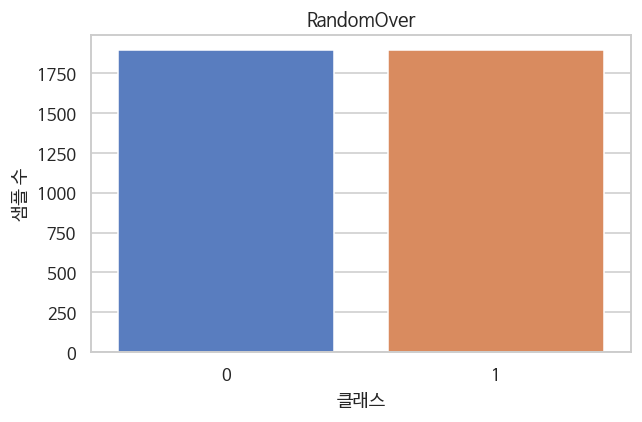

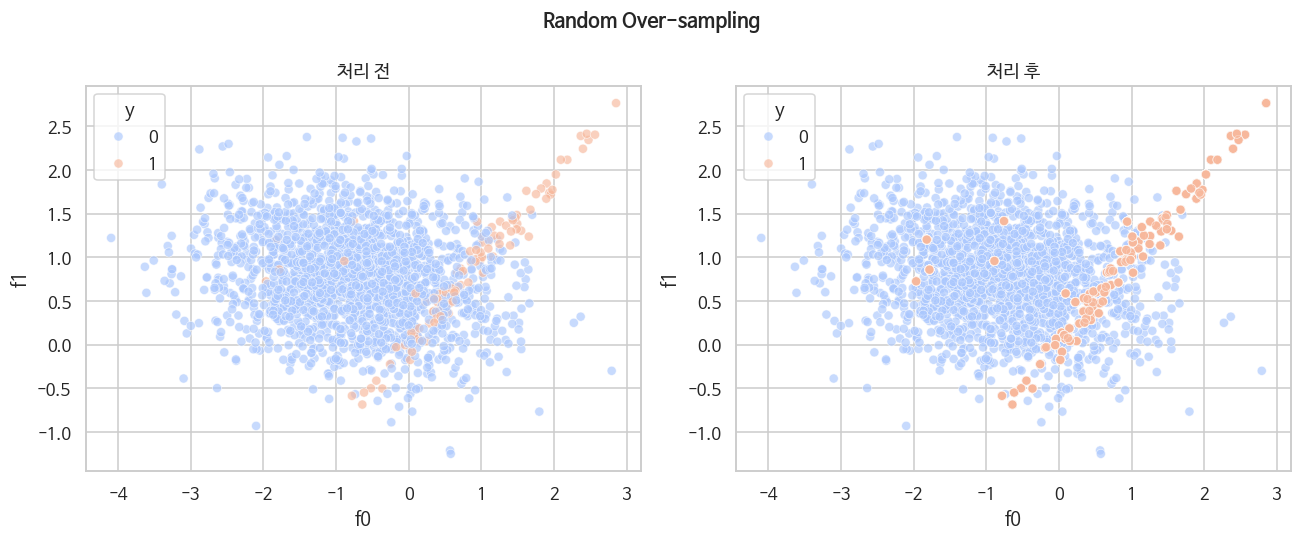

In [ ]:
# [1] RandomOverSampler 객체 생성
# - random_state=RANDOM_STATE: 복원 추출 과정에서 무작위로 선택되어 복제될 소수 클래스 샘플의 순서를 고정하여, 재현성을 확보합니다.
ros = RandomOverSampler(random_state=RANDOM_STATE)

# [2] 원본 데이터(X, y)에 높은 비율 샘플링(오버샘플링) 적용
# - 소수 클래스(C1, 약 100개)의 기존 데이터를 무작위 복원 추출하여, 다수 클래스(C0, 약 1,900개)와 동일해질 때까지 데이터를 단순히 카피(복제)합니다.
X_ros, y_ros = ros.fit_resample(X, y)

# [3] 샘플링 후의 클래스별 균형(정량적 분포)을 막대그래프로 시각화
# - 두 클래스의 데이터 총량이 정확히 상단 선(약 1,900개)에 맞춰 1:1 대칭을 이루는 모습을 확인하는 단계입니다.
fig, ax = plt.subplots(figsize=(6,4))
plot_class_balance(y_ros, 'RandomOver', ax)
plt.tight_layout()
plt.show()

# [4] 샘플링 전과 후의 2차원 공간상 분포(정성적 구조) 차이를 산점도로 비교 시각화
# - 데이터를 단순히 복사했기 때문에 공간적인 면적이나 좌표 경계면은 전혀 변하지 않는 오버샘플링의 한계를 시각적으로 증명하는 단계입니다.
plot_scatter_compare(X, y, X_ros, y_ros, title='Random Over-sampling')

#### Random Over-sampling 산점도 정밀 해석
- **1. 공간적 면적 및 외형의 불변성 (정성적 구조)**
  + 좌측('처리 전')과 우측('처리 후') 주황색 점($y=1$, 소수 클래스)들이 분포하고 있는 **전체적인 기하학적 반경이나 위치적 형태는 100% 동일**합니다.
  + 이는 기존 데이터를 기반으로 새로운 공간적 특징을 합성해낸 것이 아니라, 기존 데이터의 좌표를 그대로 복사해 붙였기 때문입니다.


- **2. 픽셀 중첩으로 인한 색상 진화 (정량적 밀도 변화)**
  + 주황색 사선 경계면의 **중앙 부근**을 자세히 보시면, '처리 전'보다 '처리 후'의 주황색 점들이 훨씬 더 **조밀하고 진하게 뭉쳐 있는 현상**을 관찰할 수 있습니다.
  + 100개 남짓하던 데이터가 약 1,900개로 늘어나는 과정에서 동일한 좌표 위에 수십 장의 데이터가 계속 겹쳐 쌓였기 때문에(Pixel Overlapping), 시각적으로 더 불투명하고 뚜렷하게 표현되는 것입니다.

- 이 결과가 의미하는 통계적 위험성 (Overfitting)
  + **수학적 무게추의 편향:** 분류 알고리즘(예: 로지스틱 회귀) 관점에서 보면, 저 주황색 점들이 위치한 특정 좌표의 **수학적 가중치(무게)가 19배 증가**한 상태입니다.
  + **결정 경계의 종속:** 모델은 저 좁고 진한 주황색 영역을 절대 틀리지 않기 위해 결정 경계선을 주황색 집단에 바짝 붙여서 학습하게 됩니다. 즉, 훈련 데이터셋 안에서는 완벽한 성능을 내는 과적합(Overfitting)이 발생합니다.
  + **일반화 성능의 부재:** 기존 경계면의 '사이 공간'이나 '외곽 영역'에 대한 정보 확장이 전혀 이루어지지 않았기 때문에, 실제 테스트 데이터셋에서 원래 위치를 아주 미세하게 벗어난 새로운 소수 데이터가 들어오면 모델은 이를 잡아내지 못하고 정상($y=0$)으로 오분류할 확률이 매우 높습니다.
  + **최종 요약:** 이 그래프는 비율은 1:1로 맞췄을지언정, "데이터의 다양성을 확보하지 못해 과적합의 위험을 고스란히 안고 있는" 무작위 오버샘플링의 한계를 시각적으로 명확히 보여줍니다. 이를 극복하기 위해 다음 단계에서 다룰 SMOTE(점과 점 사이를 선으로 이어 가상의 좌표를 만드는 기법)의 필요성을 대변하는 완벽한 디딤돌 데이터 분포입니다.


### 문제 14. SMOTE (Chawla et al., 2002)
- **원문 논문**: Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). *SMOTE: Synthetic Minority Over-sampling Technique*. Journal of Artificial Intelligence Research, 16, 321-357.
- **공식 논문 링크**: [JAIR 공식 아카이브](https://www.jair.org/index.php/jair/article/view/10302)

- **핵심 아이디어**
  + 기존 소수 클래스 데이터를 그대로 복사하여 덧붙이는 단순 복제(Random Over-sampling) 방식은 모형의 심각한 과적합(Overfitting)을 야기합니다.
  + 이를 극복하기 위해 SMOTE는 특성 공간(Feature Space) 상에서 기존 데이터들을 수학적으로 연결하여 새로운 가상의 합성 샘플(Synthetic Samples)을 생성해 냅니다.

- **작동 원리 (상세)**
  + **국소적 이웃 탐색**: 소수 클래스에 속한 임의의 샘플 $x$를 하나 선택한 뒤, 오직 소수 클래스 집단 내부에서만 가장 가까운 $k$개의 이웃($k$-NN, 통상적으로 $k=5$ 지정)을 탐색합니다.
  + **대상 선정**: 탐색된 $k$개의 이웃 중 무작위로 하나의 이웃 샘플 $x_{nn}$을 최종 선택합니다.
  + **선형 보간을 통한 합성**: 두 점 사이의 거리를 기반으로 다음 수식을 통해 새로운 가상 좌표($x_{new}$)를 계산합니다.

$$x_{new} = x + \lambda \cdot (x_{nn} - x)$$
  
  + (이때 $\lambda$는 $0$과 $1$ 사이에서 무작위로 추출되는 균등분포(Uniform Distribution) 변수입니다.)*
  + **공간적 확장**: 수학적으로 이는 샘플 $x$와 이웃 $x_{nn}$을 잇는 **기하학적 선분(Line Segment) 위의 임의의 지점**에 새로운 데이터 좌표를 찍는 것을 의미합니다. 이 과정을 통해 소수 클래스가 존재하는 영역의 확률 밀도(Density)가 자연스럽게 증가합니다.
  + **목표치 도달**: 사전에 설정한 클래스 비율 목표(예: 다수 클래스와 완벽한 1:1 균형)를 충족할 때까지 이 합성 과정을 반복 수행합니다.

- **통계적 및 기하학적 효과**
  + 특정 샘플 좌표 위로만 데이터가 무한히 겹쳐 쌓이던 단순 복제 방식과 달리, SMOTE는 소수 클래스가 군집을 이루고 있는 공간 내부의 빈틈을 촘촘히 메워줍니다.
  + 결과적으로 분류 모형이 판단하는 소수 클래스의 **결정 영역(Decision Region)을 공간적으로 유의미하게 확장**시켜 주며, 모형이 미지의 데이터(Test set)를 마주했을 때도 소수 클래스를 놓치지 않고 안정적으로 잡아낼 수 있도록 일반화 성능(Generalization)을 획기적으로 향상시킵니다.

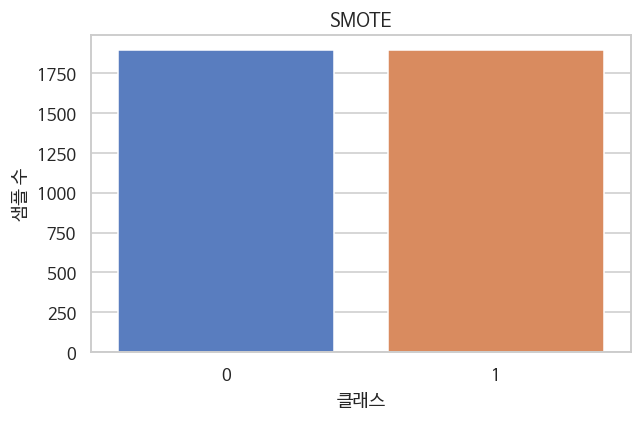

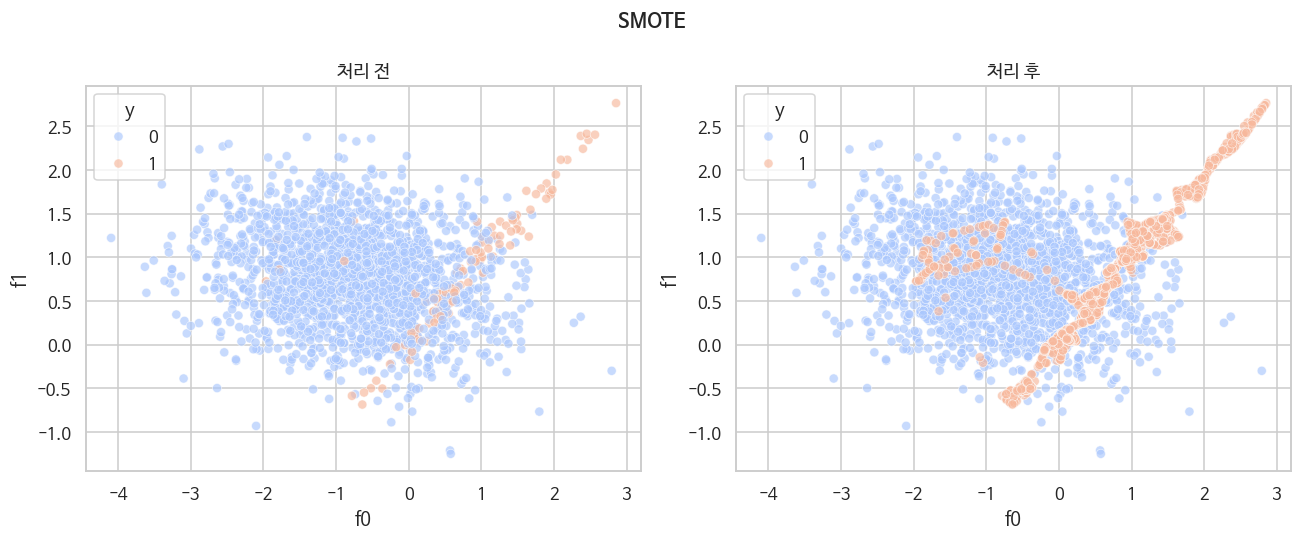

In [ ]:
# [1] SMOTE 객체 생성
# - random_state=RANDOM_STATE: 소수 클래스 내에서 k개의 이웃을 찾고, 선분 위(Uniform Distribution)에 합성 데이터를 생성할 때의 무작위 프로세스를 고정하여 재현성을 보장합니다.
# - k_neighbors=5: 가상의 데이터를 합성할 기준점이 될 소수 클래스 내부의 가장 가까운 최근접 이웃 개수를 5개로 지정합니다.
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)

# [2] 원본 데이터(X, y)에 SMOTE 합성 오버샘플링 적용
# - 기존 소수 클래스(C1) 샘플들 사이의 기하학적 빈 공간을 수학적으로 연결하여, 다수 클래스(C0)와 동일한 양(1:1 비율)이 될 때까지 새로운 가상 좌표들을 합성 생성합니다.
X_sm, y_sm = smote.fit_resample(X, y)

# [3] 샘플링 후의 클래스별 균형(정량적 분포)을 막대그래프로 시각화
# - 총 데이터 샘플 수가 대량으로 증폭되어 두 클래스가 완벽한 대칭을 이루는 정량적 변화를 확인합니다.
fig, ax = plt.subplots(figsize=(6,4))
plot_class_balance(y_sm, 'SMOTE', ax)
plt.tight_layout()
plt.show()

# [4] 샘플링 전과 후의 2차원 공간상 분포(정성적 구조) 차이를 산점도로 비교 시각화
# - 단순히 데이터가 겹쳐 쌓였던 무작위 오버샘플링과 달리, 주황색 데이터의 '영역(Decision Region)' 자체가 면적 형태로 촘촘하게 메워지며 확장되는 시각적 성과를 확인하는 핵심 단계입니다.
plot_scatter_compare(X, y, X_sm, y_sm, title='SMOTE')

#### SMOTE 산점도 정밀 해석

- **1. 선형 보간(Linear Interpolation)의 시각화 효과**
  + '처리 후' 그래프를 보면, 원래 듬성듬성 떨어져 있던 주황색 점들 사이가 마치 **그물망이나 선으로 연결된 것처럼 촘촘하게 메워진 모습**을 볼 수 있습니다.
  + 이는 알고리즘이 임의의 소수 샘플과 그 이웃($k$-NN)을 잇는 직선 방정식 위에 새로운 가상 좌표($x_{new}$)를 생성했음을 보여주는 완벽한 시각적 증거입니다.


- **2. 공간적 의의: 결정 영역(Decision Region)의 확립**
  + 단순히 한 좌표에 데이터가 겹쳐 쌓여 진해지기만 했던 Random Over-sampling과 달리, SMOTE는 주황색 클래스가 차지하는 **'기하학적 면적' 자체를 확장**했습니다.
  + 이로 인해 분류 모델은 주황색 클래스의 연속적인 패턴을 인식할 수 있게 되며, 미지의 테스트 데이터가 경계면 근처에 들어오더라도 안정적으로 잡아낼 수 있는 일반화 능력을 갖추게 됩니다.

#### [학술적 분석] 산점도에서 관찰되는 SMOTE의 치명적인 한계

- **1. 다수 클래스 중심부 침범 (노이즈 생성 현상)**
  + 파란색 점들($y=0$, 다수 클래스)의 한가운데를 관찰해 보면, '처리 전'에는 보이지 않던 **주황색 점들이 파란색 진영 깊숙이 길 모양(사선 형태)으로 침범하여 생성**된 것을 볼 수 있습니다.


- **2. 왜 이런 현상이 발생했을까요?**
  + SMOTE는 주변에 파란색 점이 있든 없든 오직 '주황색 점들끼리만' 이웃을 맺고 그 사이에 가상 데이터를 만듭니다.
  + '처리 전' 그래프를 보면 파란색 데이터 한가운데에 **노이즈 형태로 흩어져 있던 외톨이 주황색 점 몇 개**가 보입니다. SMOTE는 이 외톨이 주황색 점들끼리도 강제로 선을 이어 데이터를 합성하기 때문에, 결과적으로 **파란색 영토 한가운데에 주황색 데이터 다리를 건설해 버리는 부작용**을 낳은 것입니다.

- 연구 관점의 종합 결론
  + **장점**: 소수 클래스의 밀도와 면적을 확장하여 과적합을 방지하고 모델의 **일반화 성능 및 Recall을 획기적으로 상승**시킵니다.
  + **단점**: 클래스 간 중첩(Overlap) 구역이나 다수 클래스 내부의 이상치(Outlier) 주변에도 무차별적으로 데이터를 합성하여 **새로운 통계적 노이즈를 발생**시킵니다.
- **다음 단계로의 발전 방향:**
  + 바로 이러한 부작용(다수 클래스 영토 침범)을 해결하기 위해 데이터 과학자들은 "SMOTE로 데이터를 늘린 다음, 경계선에 지저분하게 생성된 스파이 점들을 Tomek Links나 Edited Nearest Neighbors(ENN)로 깔끔하게 정리하자!"라는 아이디어를 냈습니다.
  + 이것이 실무에서 최고 수준의 성능을 내는 **SMOTE + Tomek (하이브리드 샘플링)** 기법의 탄생 배경이 됩니다.

### 문제 15. Borderline-SMOTE (Han et al., 2005)

- **원문 논문**: Han, H., Wang, W. Y., & Mao, B. H. (2005). *Borderline-SMOTE: A new over-sampling method in imbalanced data sets learning*. International Conference on Intelligent Computing (LNCS 3644), 878-887.

- **핵심 아이디어**
  + 기존 SMOTE는 모든 소수 클래스(Minority Class) 샘플을 차별 없이 동일하게 대우하여 데이터를 합성합니다. 이 과정에서 다수 클래스(Majority Class) 진형 깊숙이 박힌 이상치(Outlier) 주변에도 데이터가 합성되어 심각한 노이즈를 생성하는 부작용이 있었습니다.
  + Borderline-SMOTE는 이러한 맹점을 해결하기 위해 **모든 소수 클래스 샘플을 주변 기하학적 환경에 따라 3가지 상태로 분류**한 뒤, 오직 분류 모델이 가장 헷갈려하는 **경계선(Borderline) 영역의 샘플들만 타겟팅하여 데이터를 합성**합니다.

- **작동 원리 (상세: 3가지 샘플 분류)**
전체 데이터 공간에서 무작위 소수 클래스 샘플 $x$를 하나 선택한 뒤, 해당 샘플의 전체 최근접 이웃($m$-NN, 보통 $m=8$ 지정)을 탐색합니다. 이때 이웃 중 **다수 클래스(Majority) 샘플의 개수**에 따라 $x$의 상태를 다음과 같이 정의합니다.

  + **Safe (안전 영역)**
    - 조건: 이웃 중 다수 클래스의 개수가 $0 \le \text{Count} < \frac{m}{2}$ 인 경우 (즉, 주변 이웃의 과반수가 같은 소수 클래스인 상태)
    - 처리: 이미 소수 클래스의 영토 안에서 안전하게 보호받고 있으므로, **SMOTE 합성 대상에서 제외**합니다.


  - **Danger (경계/위험 영역)**
    + 조건: 이웃 중 다수 클래스의 개수가 $\frac{m}{2} \le \text{Count} < m$ 인 경우 (즉, 주변 이웃의 과반수 이상이 다수 클래스에 둘러싸여 침식당하기 직전인 경계선 상태)
    + 처리: 분류 모델이 가장 오분류를 일으키기 쉬운 핵심 구간이므로, **이 Danger 샘플들만을 소수 클래스 내부의 이웃들과 연결하여 SMOTE 합성을 수행**합니다. (동일하게 선형 보간 기법 적용)


- **Noise (노이즈/이상치 영역)**
    + 조건: 이웃 중 다수 클래스의 개수가 $\text{Count} = m$ 인 경우 (즉, 주변 8개의 이웃이 예외 없이 전부 다수 클래스인 상태)
    + 처리: 다수 클래스 영토 한복판에 홀로 고립된 외톨이(Outlier)이므로, 데이터 학습에 혼선을 주지 않도록 **SMOTE 합성 대상에서 철저히 배제**합니다.

- 통계적 및 기하학적 효과 (SMOTE와의 차이)
  + **결정 경계의 선명화**: SMOTE처럼 파란색(다수) 진형 한가운데에 뚱뚱한 주황색(소수) 다리를 놓아 노이즈를 만드는 현상이 발생하지 않습니다.
  + **소수 클래스 수비력 강화**: 두 클래스가 가장 치열하게 맞물려 있는 '최전방 전투 구역(Danger)'에만 정밀하게 소수 데이터를 집중 증식시키기 때문에, 분류 모델이 경계면에서 소수 클래스를 놓치지 않고 잡아내는 **Recall(재현율) 성능을 효율적이고 깔끔하게 끌어올리는 효과**를 발휘합니다.

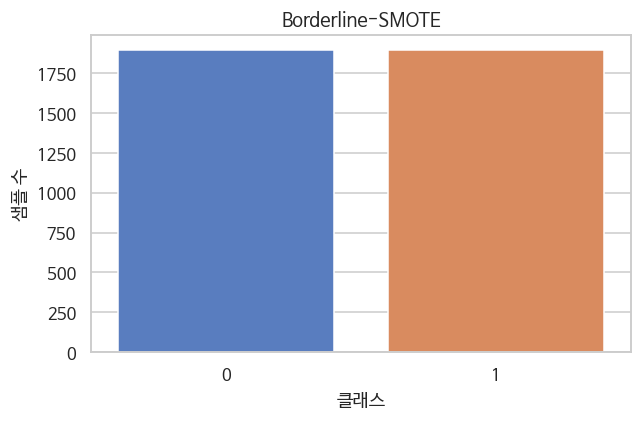

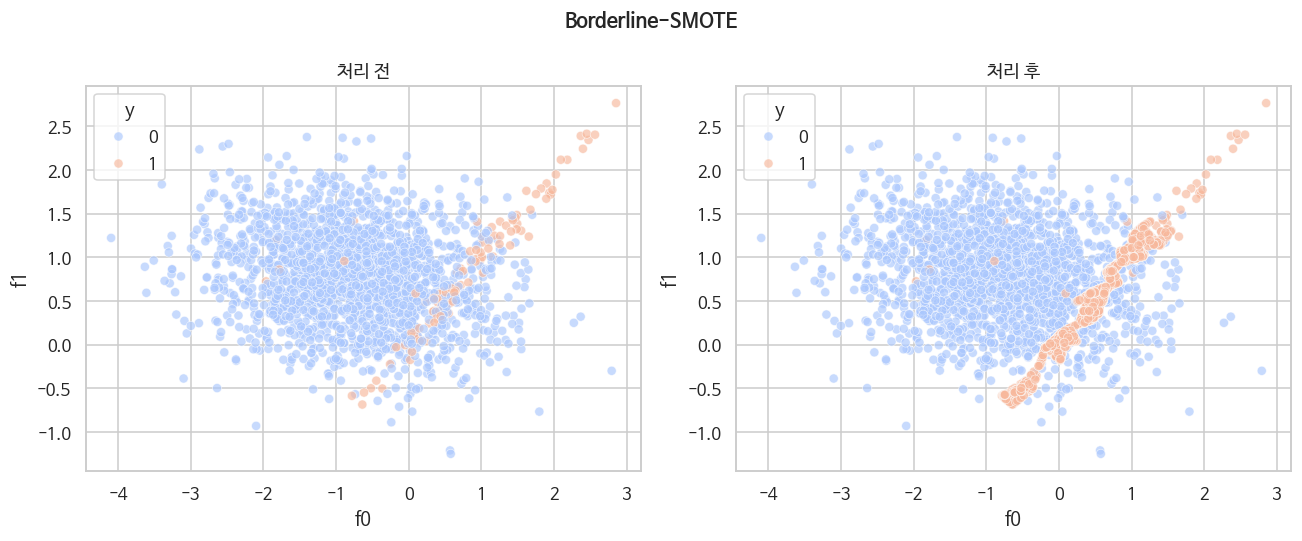

In [ ]:
from imblearn.over_sampling import BorderlineSMOTE

# [1] Borderline-SMOTE 객체 생성
# - k_neighbors=5: 생성된 'Danger' 샘플들을 서로 연결하여 합성 데이터를 만들 때 사용할 소수 클래스 내부 이웃 수
# - m_neighbors=8: [핵심] 해당 샘플이 Safe/Danger/Noise 중 어디에 속하는지 판별하기 위해 탐색할 전체(전체 클래스 대상) 이웃 수
# - kind='borderline-1': Danger 샘플과 '소수 클래스 이웃' 사이의 선분 위에만 데이터를 합성하는 표준 모드 지정
bsmote = BorderlineSMOTE(random_state=RANDOM_STATE, k_neighbors=5, m_neighbors=8, kind='borderline-1')

# [2] 원본 데이터(X, y)에 Borderline-SMOTE 전처리 적용
# - 다수 클래스 중심부에 고립된 Noise는 배제하고, 경계선의 Danger 샘플들만 타겟팅하여 데이터를 1:1 비율까지 합성합니다.
X_bs, y_bs = bsmote.fit_resample(X, y)

# [3] 샘플링 후의 클래스별 균형(정량적 분포)을 막대그래프로 시각화
fig, ax = plt.subplots(figsize=(6,4))
plot_class_balance(y_bs, 'Borderline-SMOTE', ax)
plt.tight_layout()
plt.show()

# [4] 샘플링 전과 후의 2차원 공간상 분포(정성적 구조) 차이를 산점도로 비교 시각화
# - 일반 SMOTE와 달리 다수 클래스(파란 점) 한복판을 침범하지 않고, 오직 경계선 쪽에만 주황색 점들이 집중 합성되었는지 육안 검증합니다.
plot_scatter_compare(X, y, X_bs, y_bs, title='Borderline-SMOTE')

#### Borderline-SMOTE 산점도 핵심 요약

- **파란색 영토 진입 차단 (노이즈 방지)**
  + 일반 SMOTE에서 파란색 점들($y=0$) 한가운데를 무차별적으로 관통하던 주황색 데이터 다리가 **오른쪽 그래프에서는 흔적도 없이 사라졌습니다.**
  + 다수 클래스 진영 깊숙이 박혀 있던 외톨이 소수 샘플들을 `Noise(이상치)`로 규정하여 합성 대상에서 철저히 배제했기 때문입니다.

- **국소적 최전방 울타리 형성 (Danger 구역 증식)**
  + 오직 두 클래스가 가장 치열하게 맞물려 있는 사선 경계면(Danger 구역)을 따라서만 주황색 점들이 촘촘하고 두터운 울타리 형태로 집중 합성되었습니다.

- **"쓸데없는 아웃라이어는 버리고, 분류 모델이 가장 헷갈려하는 최전방 경계선만 정밀 타겟팅하여 수비력을 보강한 이상적인 오버샘플링 결과입니다."**

## titanic 예제 최종 비교표


==================== [1. 샘플링 방법론별 최종 성능 정량 지표] ====================
          Method  Recall (생존자 검출률)  F1-Score (종합 균형점수)  Accuracy (전체 정확도)
        Baseline          0.416667            0.555556           0.954802
     RandomUnder          0.750000            0.352941           0.813559
      TomekLinks          0.416667            0.434783           0.926554
             CNN          0.500000            0.480000           0.926554
      RandomOver          0.583333            0.518519           0.926554
           SMOTE          0.500000            0.500000           0.932203
Borderline-SMOTE          0.500000            0.545455           0.943503



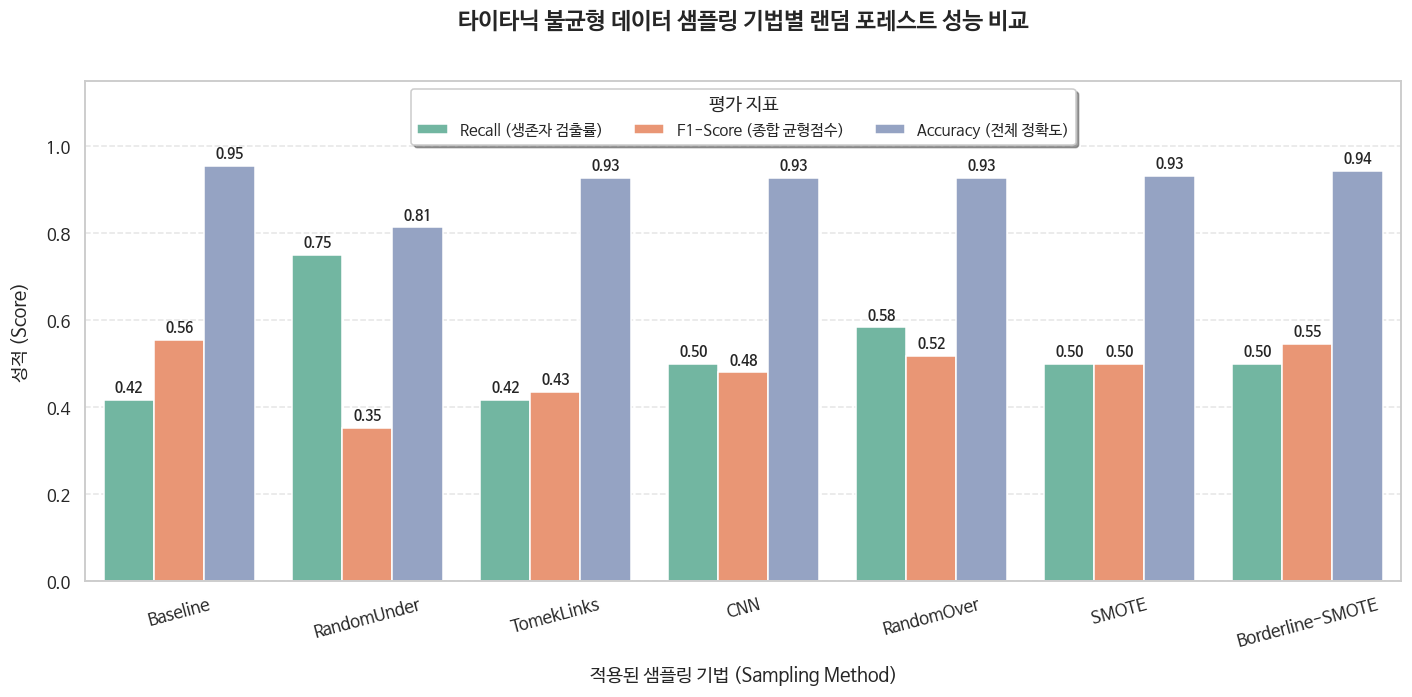

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Imbalanced-Learn 샘플링 및 전용 파이프라인 호출
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, CondensedNearestNeighbour
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE

# -------------------------------------------------------------------------
# 1. 의도적 불균형 타이타닉 데이터셋 정의
# -------------------------------------------------------------------------
raw_data = sns.load_dataset('titanic')  # seaborn 내장 타이타닉 데이터셋 로드

# 모델 입력으로 사용할 특성(feature) 컬럼만 선택하여 복사본 생성
X = raw_data[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']].copy()
y = raw_data['survived'].values  # 타깃(생존 여부) 값 배열

# 실무 데이터 환경 묘사를 위한 극심한 불균형 상태(IR 약 15:1) 인위적 유도
np.random.seed(42)  # 재현성을 위한 난수 시드 고정
survived_idx = np.where(y == 1)[0]  # 생존자(양성 클래스) 인덱스 추출
dead_idx = np.where(y == 0)[0]      # 사망자(음성 클래스) 인덱스 추출 (전부 유지)

# 생존자 중 40명만 무작위로 남겨서 클래스 불균형을 인위적으로 심하게 만듦
keep_survived_idx = np.random.choice(survived_idx, size=40, replace=False)

# 사망자 전체 + 생존자 40명만 합쳐서 최종 불균형 인덱스 구성
final_idx = np.concatenate([dead_idx, keep_survived_idx])

# 위에서 만든 인덱스로 불균형 데이터셋 최종 추출
X_imbalanced = X.iloc[final_idx]
y_imbalanced = y[final_idx]

# 데이터 분할 (Data Leakage 차단)
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X_imbalanced, y_imbalanced,
    test_size=0.3,          # 테스트셋 비율 30%
    stratify=y_imbalanced,  # 불균형 비율을 train/test에 동일하게 유지
    random_state=RANDOM_STATE
)

# -------------------------------------------------------------------------
# 2. 기초 수치형/범주형 변수 전처리기(ColumnTransformer) 구성
# -------------------------------------------------------------------------
numeric_features = ['age', 'sibsp', 'parch', 'fare']  # 수치형 컬럼 목록
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # 결측치는 중앙값으로 대체
    ('scaler', StandardScaler())                     # 표준화(평균 0, 분산 1)
])

categorical_features = ['sex', 'pclass', 'embarked']  # 범주형 컬럼 목록
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # 결측치는 최빈값으로 대체
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    # drop='first': 다중공선성 방지 위해 첫 범주 제거
    # handle_unknown='ignore': 학습 시 없던 범주가 나와도 에러 없이 처리
])

# 수치형/범주형 전처리를 하나의 파이프라인으로 결합
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# -------------------------------------------------------------------------
# 3. 비교 실험군 정의 및 루프 실행 파이프라인
# -------------------------------------------------------------------------
# 실험할 샘플링 기법 리스트 정의 (None은 대조군 Baseline을 의미)
samplers = {
    'Baseline': None,                                                     # 샘플링 미적용 대조군
    'RandomUnder': RandomUnderSampler(random_state=RANDOM_STATE),         # 다수 클래스 무작위 언더샘플링
    'TomekLinks': TomekLinks(sampling_strategy='majority'),               # 경계 노이즈 제거형 언더샘플링
    'CNN': CondensedNearestNeighbour(random_state=RANDOM_STATE),          # 최근접이웃 기반 압축 언더샘플링
    'RandomOver': RandomOverSampler(random_state=RANDOM_STATE),           # 소수 클래스 무작위 오버샘플링
    'SMOTE': SMOTE(random_state=RANDOM_STATE, k_neighbors=3),             # 합성 소수 샘플 생성(SMOTE)
    'Borderline-SMOTE': BorderlineSMOTE(                                  # 경계 영역 위주 SMOTE 변형
        random_state=RANDOM_STATE, k_neighbors=3, m_neighbors=6, kind='borderline-1'
    )
}

results = []  # 각 기법별 성능 지표를 저장할 리스트

for name, sampler in samplers.items():
    # 파이프라인 단계를 동적으로 구성 (전처리 → (샘플링) → 분류기)
    steps = [('preprocessor', preprocessor)]

    if sampler is not None:
        steps.append(('sampler', sampler))  # Baseline이 아니면 샘플링 단계 추가

    # 랜덤포레스트 분류기 추가 (트리 100개, 최대 깊이 6으로 과적합 방지)
    steps.append(('classifier', RandomForestClassifier(n_estimators=100, max_depth=6, random_state=RANDOM_STATE)))

    # 엔드투엔드 파이프라인 구축 및 학습
    pipeline = ImbPipeline(steps=steps)
    pipeline.fit(X_train, y_train)  # 학습 데이터로 파이프라인 전체 학습 (샘플링은 train에만 적용됨)

    # 예측 및 평가지표 사전 파싱
    rep = classification_report(y_test, pipeline.predict(X_test), output_dict=True, zero_division=0)

    # 시각화 데이터 구조 생성을 고려하여 정량 지표 누적
    results.append({
        'Method': name,
        'Recall (생존자 검출률)': rep['1']['recall'],       # 실제 생존자 중 맞춘 비율
        'F1-Score (종합 균형점수)': rep['1']['f1-score'],   # 정밀도와 재현율의 조화평균
        'Accuracy (전체 정확도)': rep['accuracy']           # 전체 샘플 중 정답 비율
    })

# 비교 분석용 통합 결과 데이터프레임 빌드
df_results = pd.DataFrame(results)

print("==================== [1. 샘플링 방법론별 최종 성능 정량 지표] ====================")
print(df_results.to_string(index=False))
print("==================================================================================\n")

# -------------------------------------------------------------------------
# 4. 데이터 멜팅(Melting) 및 가독성 높은 비교 시각화 (fig, ax 적용)
# -------------------------------------------------------------------------

# 시본(Seaborn) 바 차트 매핑을 위한 데이터 재구조화 (Wide to Long format)
# Method 컬럼은 고정하고 나머지 지표 컬럼들을 Metric/Score 두 컬럼으로 녹여냄
df_melted = df_results.melt(id_vars='Method', var_name='Metric', value_name='Score')

# 객체지향형(fig, ax) 플롯 캔버스 선언
fig, ax = plt.subplots(figsize=(13, 6.5))  # 범례 공간 확보를 위해 높이를 6.5로 약간 확장

# 복합 막대그래프(Grouped Bar Chart) 생성 (Method별로 3개 지표 막대를 묶어서 표시)
sns.barplot(data=df_melted, x='Method', y='Score', hue='Metric', palette='Set2', ax=ax)

# 그래프 디테일 및 가독성 튜닝
ax.set_title('타이타닉 불균형 데이터 샘플링 기법별 랜덤 포레스트 성능 비교',
             fontsize=15, fontweight='bold', pad=35)  # 타이틀 패딩 늘림 (범례와 겹치지 않도록)
ax.set_xlabel('적용된 샘플링 기법 (Sampling Method)', fontsize=12, labelpad=10)
ax.set_ylabel('성적 (Score)', fontsize=12, labelpad=10)
ax.set_ylim(0, 1.15)  # 상단 수치 텍스트와 범례 공간을 위해 최대 범위를 1.15로 상향
ax.grid(axis='y', linestyle='--', alpha=0.5)  # y축 보조선으로 값 비교 용이하게

# -------------------------------------------------------------------------
# [수정] 범례를 제목 아래, 막대그래프 상단 중앙으로 배치
# -------------------------------------------------------------------------
# loc='upper center': 상단 중앙 기준
# bbox_to_anchor=(0.5, 1.0): x축은 중앙(0.5), y축은 그래프 상단 경계선(1.0)에 맞춤
# ncol=3: 범례 아이템 3개를 가로 한 줄로 나란히 배치
ax.legend(title='평가 지표', loc='upper center', bbox_to_anchor=(0.5, 1.0),
          ncol=3, frameon=True, shadow=True, fontsize=10)

plt.xticks(rotation=15)  # x축 라벨을 15도 회전시켜 겹침 방지

# 수치 텍스트 탑재 (각 막대 위에 점수 표기)
for p in ax.patches:  # ax에 그려진 모든 막대(patch) 순회
    if p.get_height() > 0:  # 높이가 0보다 큰 막대만 라벨 표시 (빈 막대 제외)
        ax.annotate(
            f"{p.get_height():.2f}",                          # 소수점 둘째 자리까지 표시
            (p.get_x() + p.get_width() / 2., p.get_height()),  # 막대 중앙 상단 좌표
            ha='center', va='center',
            xytext=(0, 8), textcoords='offset points',        # 막대보다 8pt 위에 배치
            fontsize=9, fontweight='semibold'
        )

plt.tight_layout()  # 레이아웃 자동 조정 (라벨/제목 겹침 방지)
plt.show()  # 그래프 출력

### 결과 해석
- **Baseline (앙상블 강건성과 통계적 착시)**
  + **결과**: 데이터 원본 분포를 유지하여 전체 정확도 $95.5\%$, F1-Score $0.556$을 기록함.
  + **의의**: 랜덤 포레스트 특유의 무작위 특성 선택 및 배깅(Bagging) 메커니즘이 불균형 환경에서 다수 클래스로의 전면 편향을 일정 수준 스스로 방어(Robustness)하고 있음을 증명함.
  + **한계**: 그러나 실제 소수 클래스 재현율(Recall)은 $0.417$에 그쳐, 오분류 손실 최적화에 따른 결정 경계의 수축 현상이 여전히 존재함.


- **Random Under-sampling (정보 유실과 분포 왜곡)**
  + **결과**: 다수 클래스 샘플을 소수 클래스 빈도로 강제 매칭하여 재현율을 $0.750$까지 폭발적으로 견인함.
  + **한계**: 모형의 사전 확률(Prior Probability) 편향은 해소했으나, 대량의 데이터 소거에 따른 극심한 정보 손실(Information Loss)을 유발함. 그 결과 위양성(오탐)이 폭증하여 종합 균형 점수인 F1-Score가 $0.353$으로 참담하게 급락함.


- **Tomek Links & CNN (비선형 모형 내 언더샘플링의 한계)**
  + **결과**: 경계면 노이즈 정제(Tomek) 및 공간 구조 압축(CNN)을 수행했으나 재현율은 각각 $0.417$, $0.500$으로 제한적인 상승에 그침.
  + **한계**: 계층적 공간 분할을 수행하는 의사결정 나무 기반 앙상블 모형 특성상, 데이터의 국소적 밀도나 중복성 제거만으로는 비선형 경계면의 확률 밀도 함수(PDF)를 유의미하게 변형시키기 어렵다는 방법론적 한계를 시사함.


- **SMOTE vs Borderline-SMOTE (공간 합성 오버샘플링의 정밀도 격차)**
  + **SMOTE의 한계 (F1: $0.500$)**: 소수 샘플 간 무차별적 선형 보간을 수행하는 과정에서, 다수 클래스 진영 내부에 박힌 이상치(Outlier) 주변에도 가상 데이터를 합성하여 랜덤 포레스트의 노드 분기 규칙을 교란(Noise Generation)하는 부작용을 낳음.
  + **Borderline-SMOTE의 우수성 (F1: $0.545$, Accuracy: $0.944$)**: 주변 환경 관찰을 통해 분류가 까다로운 최전방 위험 지대(**Danger 구역**)만을 정밀 조준 증식시킴. 결과적으로 다수 클래스 중심부의 무결성을 해치지 않으면서도 모형이 더 명확하고 정교한 비선형 결정 영역(Decision Region)을 확립하도록 지원하여 가장 우수한 통계적 효율성을 입증함.

### 논문 정리 및 체크리스트

**[개념 및 논문 리뷰]**

| 기법 | 논문 (저자, 연도) | 핵심 한 줄 |
| --- | --- | --- |
| **Tomek Links** | Tomek (1976), IEEE TSMC 6(11):769-772 | 이종간 Nearest Neighbor 쌍에서 **Majority Class(다수 클래스)** 제거 → 경계면 정제 |
| **CNN** | Hart (1968), IEEE TIT 14(3):515-516 | 1-NN 오분류가 없는 최소한의 정예 집합 구성 → 데이터 구조 보존 |
| **SMOTE** | Chawla et al. (2002), JAIR 16:321-357 | 소수 데이터간의 $k$-NN 선분 보간 합성 → **Minority Class(소수 클래스)** 밀도 및 영역 증가 |
| **Borderline-SMOTE** | Han et al. (2005), LNCS 3644:878-887 | 주변 환경을 Safe/Danger/Noise로 분류 → 경계선에 걸친 **Danger 영역만 타겟팅하여 SMOTE 적용** |

---

**실무 체크리스트**

1. **Countplot**을 통해 데이터셋의 불균형 비율(Imbalance Ratio, IR) 정량적 확인
2. **Baseline 모형 구축**: 전체 정확도의 착시에 속지 않고, 혼동 행렬(Confusion Matrix)과 **Minority Class의 Recall(재현율) 및 F1-score**를 최우선 지표로 평가
3. **데이터 누수(Data Leakage) 차단**: 리샘플링(샘플링 전처리)은 **오직 Train Set에만 적용**하며, Test Set은 원본 분포 그대로 유지
4. **산점도(Scatter plot) 전·후 비교**: 특성 공간 상에서 데이터의 합성 및 삭제 패턴을 육안으로 검증하여 이상치(Outlier) 형성 여부 확인
5. **통계적 검정 수행**: Mann-Whitney U test 또는 독립표본 t-test를 통해 샘플링 전후 특성별 확률 분포의 왜곡이나 변형이 일어났는지 확인
6. **비용 기반 최적화**: 샘플링 전처리에만 의존하지 않고, 알고리즘 자체의 `class_weight` 조정, 분류 임계값 조정(Threshold Tuning), 그리고 평가 지표로서 PR-AUC(Precision-Recall AUC)를 반드시 **병행**하여 종합 평가